### 连接到虚拟机的apache spark

In [ ]:
from pyspark.sql import SparkSession
from pyspark import StorageLevel
from time import perf_counter

spark = SparkSession.builder \
    .remote("sc://<your-vm-hostname>:15002") \
    .getOrCreate()

print("连接成功！Spark 版本:", spark.version)
# spark.range(10).show()
spark.sql("SHOW DATABASES").show()

spark.conf.set("spark.sql.parquet.outputTimestampType", "TIMESTAMP_MICROS")
spark.conf.set("spark.sql.legacy.parquet.nanosAsLong", "true")

连接成功！Spark 版本: 3.5.7
+---------+
|namespace|
+---------+
|  default|
+---------+



### 连接到虚拟机的Hadoop hdfs

In [2]:
# 2) HDFS 路径
hdfs_base = "hdfs://localhost:9000"
geo_path = f"{hdfs_base}/spark/httplog_analytics/01_geo_dim.parquet"
url_path = f"{hdfs_base}/spark/httplog_analytics/02_url_category_dim.parquet"
log_path = f"{hdfs_base}/spark/httplog_analytics/03_http_logs.parquet"

print("正在读取 HDFS 中的 Parquet 文件...")
geo_df = spark.read.parquet(geo_path)
url_df = spark.read.parquet(url_path)
logs_df = spark.read.parquet(log_path)

print("geo_df 记录数:", geo_df.count())
print("url_df 记录数:", url_df.count())
print("logs_df 记录数:", logs_df.count())

# 3) 查看表结构
print("\n=== geo_dim schema ===")
geo_df.printSchema()
print("\n=== url_category_dim schema ===")
url_df.printSchema()
print("\n=== http_logs schema ===")
logs_df.printSchema()

正在读取 HDFS 中的 Parquet 文件...
geo_df 记录数: 32
url_df 记录数: 800
logs_df 记录数: 600000

=== geo_dim schema ===
root
 |-- country_code: string (nullable = true)
 |-- country_name: string (nullable = true)
 |-- region: string (nullable = true)
 |-- continent: string (nullable = true)
 |-- is_high_risk: boolean (nullable = true)


=== url_category_dim schema ===
root
 |-- path_pattern: string (nullable = true)
 |-- category: string (nullable = true)
 |-- is_api: boolean (nullable = true)
 |-- is_static: boolean (nullable = true)
 |-- priority: long (nullable = true)


=== http_logs schema ===
root
 |-- log_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- date: string (nullable = true)
 |-- hour: long (nullable = true)
 |-- ip: string (nullable = true)
 |-- method: string (nullable = true)
 |-- url: string (nullable = true)
 |-- path: string (nullable = true)
 |-- status_code: long (nullable = true)
 |-- response_time_ms: long (nullable = true)
 |-- bytes: long (nullable = t

### 几张原始数据表进行并联

In [3]:
# 5) 联表：日志 + geo_dim + url_category_dim
# 5) 联表：使用 broadcast join（对 small dim 表使用 broadcast）
from pyspark.sql.functions import broadcast
log_geo_df = logs_df.join(
    broadcast(geo_df),
    logs_df["country"] == geo_df["country_code"],
    "left"
)

log_geo_url_df = log_geo_df.join(
    broadcast(url_df),
    log_geo_df["path"] == url_df["path_pattern"],
    "left"
)

# 对刚创建的中间表做一次 persist（用于后续多次聚合）
log_geo_url_df = log_geo_url_df.repartition("country")  # 按业务常用维度分区
log_geo_url_df.persist(StorageLevel.MEMORY_AND_DISK)

# 6) 关键字段展示
print("\n=== 采样数据 ===")
log_geo_url_df.select(
    "log_id","timestamp","country","country_name","region","continent","path","category","status_code","response_time_ms"
).show(10, truncate=False)



=== 采样数据 ===
+-----------------+-------------------+-------+------------+--------------+---------+-----------------------+--------+-----------+----------------+
|log_id           |timestamp          |country|country_name|region        |continent|path                   |category|status_code|response_time_ms|
+-----------------+-------------------+-------+------------+--------------+---------+-----------------------+--------+-----------+----------------+
|20240107-00000028|1704649516000000000|UA     |Ukraine     |Eastern Europe|Europe   |/s/coffee              |search  |200        |2878            |
|20240107-00000173|1704604607000000000|UA     |Ukraine     |Eastern Europe|Europe   |/list/electronics      |category|200        |264             |
|20240106-00000245|1704567155000000000|UA     |Ukraine     |Eastern Europe|Europe   |/goods/1780            |product |404        |3056            |
|20240102-00000271|1704213080000000000|UA     |Ukraine     |Eastern Europe|Europe   |/manage/syste

### 时间单位转换

In [4]:
# 将原始整数/字符串时间戳转换为 Spark 的 timestamp 类型并生成新列 ts（不修改原表）
from pyspark.sql import functions as F

# 判断 timestamp 单位并生成 ts (timestamp)
if "ts" not in log_geo_url_df.columns:
    max_ts = log_geo_url_df.agg(F.max("timestamp")).collect()[0][0]
    def to_ts_expr(col):
        if max_ts is None:
            return F.to_timestamp(F.col(col).cast("string"))
        if max_ts > 1e17:
            return F.to_timestamp((F.col(col) / F.lit(1e9)).cast("double"))
        elif max_ts > 1e14:
            return F.to_timestamp((F.col(col) / F.lit(1e6)).cast("double"))
        elif max_ts > 1e11:
            return F.to_timestamp((F.col(col) / F.lit(1e3)).cast("double"))
        else:
            return F.to_timestamp(F.from_unixtime(F.col(col).cast("long")))
    log_ts = log_geo_url_df.withColumn("ts", to_ts_expr("timestamp"))
else:
    log_ts = log_geo_url_df

# 生成 log_ts（保留原表不变）
log_ts.select("timestamp","ts").show(5, truncate=False)

+-------------------+-------------------+
|timestamp          |ts                 |
+-------------------+-------------------+
|1704649516000000000|2024-01-08 01:45:16|
|1704604607000000000|2024-01-07 13:16:47|
|1704567155000000000|2024-01-07 02:52:35|
|1704213080000000000|2024-01-03 00:31:20|
|1704316989000000000|2024-01-04 05:23:09|
+-------------------+-------------------+
only showing top 5 rows



In [5]:
out_dir = r"G:\Log-Spark-Insight-Analysis-v2\output_abnormal_analytics"
import os
os.makedirs(out_dir, exist_ok=True)

### 识别高频访问IP（1分钟超过1000请求）

In [ ]:
# 这个cell的主要内容：
# 对日志按不同短时窗口统计每个 IP 的访问量和行为（如唯一路径、请求方法占比、QPS 等），
# 找出高频/头部 IP 并保存结果，同时为这些关键 IP 生成按分钟的时间序列以便进一步分析和定位异常。

from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 窗口长度/滑动步长示例（字符串格式）
windows = {
    "1min": ("1 minute", "1 minute"),
    "30s": ("30 seconds", "30 seconds"),
    "10s": ("10 seconds", "10 seconds")
}

# 1) 按窗口按 IP 聚合：request_count, qps(基于窗口长度), uniq_paths, uniq_user_agents, method 分布, avg/max bytes
agg_per_window = {}
for k,(win_len, slide) in windows.items():
    wcol = F.window(F.col("ts"), win_len, slide).alias("w")
    grouped = (
        log_ts
        .groupBy("ip", wcol)
        .agg(
            F.count("*").alias("request_count"),
            (F.count("*") / F.lit( F.expr(f"interval {win_len}") )) # placeholder, will compute qps below
        )
    )
    # 更完整计算：
    grouped = (
        log_ts
        .groupBy("ip", F.window(F.col("ts"), win_len, slide).alias("window"))
        .agg(
            F.count("*").alias("request_count"),
            F.countDistinct("path").alias("unique_paths"),
            F.countDistinct("user_agent").alias("unique_user_agents"),
            F.expr("sum(case when method = 'GET' then 1 else 0 end)").alias("get_count"),
            F.expr("sum(case when method = 'POST' then 1 else 0 end)").alias("post_count"),
            F.expr("sum(case when method not in ('GET','POST') then 1 else 0 end)").alias("other_method_count"),
            F.avg(F.col("bytes")).alias("avg_bytes"),
            F.max(F.col("bytes")).alias("max_bytes")
        )
        .withColumn("window_seconds", 
            F.expr(
                "CASE WHEN " +
                ("{} > 0".format(1)) + 
                " THEN " + 
                ( "CAST(" + ("CASE WHEN '{}'='1 minute' THEN 60 WHEN '{}'='30 seconds' THEN 30 WHEN '{}'='10 seconds' THEN 10 END".format(win_len, win_len, win_len)) + " AS INT)" ) +
                " ELSE 60 END"
            )
        )
    )
    # 由于上面用表达式复杂，这里直接把窗口长度解析为秒：
    secs = 60 if win_len == "1 minute" else (30 if win_len == "30 seconds" else 10)
    grouped = grouped.withColumn("qps", F.col("request_count") / F.lit(secs))
    # 方法占比
    grouped = grouped.withColumn("get_pct", F.col("get_count") / F.col("request_count") * 100)\
                     .withColumn("post_pct", F.col("post_count") / F.col("request_count") * 100)\
                     .withColumn("other_pct", F.col("other_method_count") / F.col("request_count") * 100)
    agg_per_window[k] = grouped

# 示例：展示 1分钟窗口 Top 20 高频 IP（按 request_count）
print("=== Top 20 high-frequency IPs (1-minute window) ===")
top1m = (agg_per_window["1min"]
         .orderBy(F.col("request_count").desc())
         .limit(20))
top1m.show(truncate=False)
pd_top1m = top1m.toPandas()
pd_top1m.attrs.clear()
pd_top1m.to_parquet(os.path.join(out_dir, "01_top1m_high_freq_ip.parquet"), index=False)


# 2) 全局 Top-N（跨所有时间）用于计算头部效应：按 IP 总请求量排序，计算占比
# 先计算每个 ip 的总请求数（单独保存）
total_requests = log_ts.count()
ip_total = log_ts.groupBy("ip").agg(F.count("*").alias("total_requests"))

# 准备 ip->country 映射（按出现次数取最常见）
ip_country_counts = log_ts.groupBy("ip","country","country_name").count()
w = Window.partitionBy("ip").orderBy(F.desc("count"))
ip_country_mode = (ip_country_counts
                  .withColumn("rn", F.row_number().over(w))
                  .filter(F.col("rn")==1)
                  .select("ip","country","country_name"))

# join 后再计算百分比并取 Top20（先 order 再 limit 确保正确）
top20_global = (ip_total
                .join(ip_country_mode, on="ip", how="left")
                .withColumn("pct_of_total", F.col("total_requests") / F.lit(total_requests) * 100)
                .orderBy(F.desc("total_requests"))
                .limit(20))
print("=== Top 20 IPs by total requests (global) ===")
top20_global.show(20, truncate=False)

# 头部效应：Top-20 占比合计
top20_sum = top20_global.agg(F.sum("pct_of_total").alias("top20_pct_sum")).collect()[0]["top20_pct_sum"]
print(f"Top-20 IPs account for {top20_sum:.2f}% of total requests")

# 3) 将 Top1m 和 ip_total 等结果保存（可选）

pd_top20 = top20_global.toPandas()
pd_top20.attrs.clear()
pd_top20.to_parquet(os.path.join(out_dir, "02_top20_high_freq_global_ip.parquet"), index=False)

# 4) 可选：为 Top-N IP 做更细的衍生特征时间序列（示例：取 top IP 列表后在原数据中按 minute 聚合）
top_ips = [r["ip"] for r in top20_global.select("ip").collect()]
if top_ips:
    ts_top = (log_ts.filter(F.col("ip").isin(top_ips))
              .withColumn("date_min", F.date_format(F.col("ts"), "yyyy-MM-dd HH:mm"))
              .groupBy("ip", "date_min")
              .agg(
                  F.count("*").alias("req_count"),
                  F.countDistinct("path").alias("unique_paths"),
                  F.countDistinct("user_agent").alias("unique_user_agents"),
                  F.avg("bytes").alias("avg_bytes"),
                  F.max("bytes").alias("max_bytes")
              )
              .orderBy("ip", "date_min")
             )
    pd_ts_top = ts_top.toPandas()
    pd_ts_top.attrs.clear()
    pd_ts_top.to_parquet(os.path.join(out_dir, "03_top_high_freq_ips_time_series.parquet"), index=False)
    print("Saved top IPs time series to output_abnormal_analytics")



=== Top 20 high-frequency IPs (1-minute window) ===
+------------+------------------------------------------+-------------+------------+------------------+---------+----------+------------------+------------------+---------+--------------+-------------------+-----------------+-----------------+-----------------+
|ip          |window                                    |request_count|unique_paths|unique_user_agents|get_count|post_count|other_method_count|avg_bytes         |max_bytes|window_seconds|qps                |get_pct          |post_pct         |other_pct        |
+------------+------------------------------------------+-------------+------------+------------------+---------+----------+------------------+------------------+---------+--------------+-------------------+-----------------+-----------------+-----------------+
|10.10.10.10 |{2024-01-01 21:58:00, 2024-01-01 21:59:00}|4            |4           |2                 |1        |1         |2                 |107481.0          |

### URL状态码分布 - 忽略

### HTTP 异常（4xx/5xx/404/500）深入分析


=== 3+. HTTP 异常（4xx/5xx/404/500）深入分析 ===
total requests: 600000
+-----------+------+------------------+
|status_code|count |pct               |
+-----------+------+------------------+
|200        |416614|69.43566666666666 |
|500        |46908 |7.818             |
|404        |46694 |7.782333333333333 |
|302        |42020 |7.003333333333334 |
|301        |41876 |6.979333333333333 |
|503        |5141  |0.8568333333333334|
|403        |696   |0.116             |
|401        |51    |0.0085            |
+-----------+------+------------------+

+--------------+---------+---------+---------+---------+-----------------+-----------------+-----------------+------------+
|total_requests|4xx_count|5xx_count|404_count|500_count|4xx_rate_pct     |5xx_rate_pct     |404_rate_pct     |500_rate_pct|
+--------------+---------+---------+---------+---------+-----------------+-----------------+-----------------+------------+
|600000        |47441    |52049    |46694    |46908    |7.906833333333334|8.674833

<Figure size 1000x500 with 0 Axes>

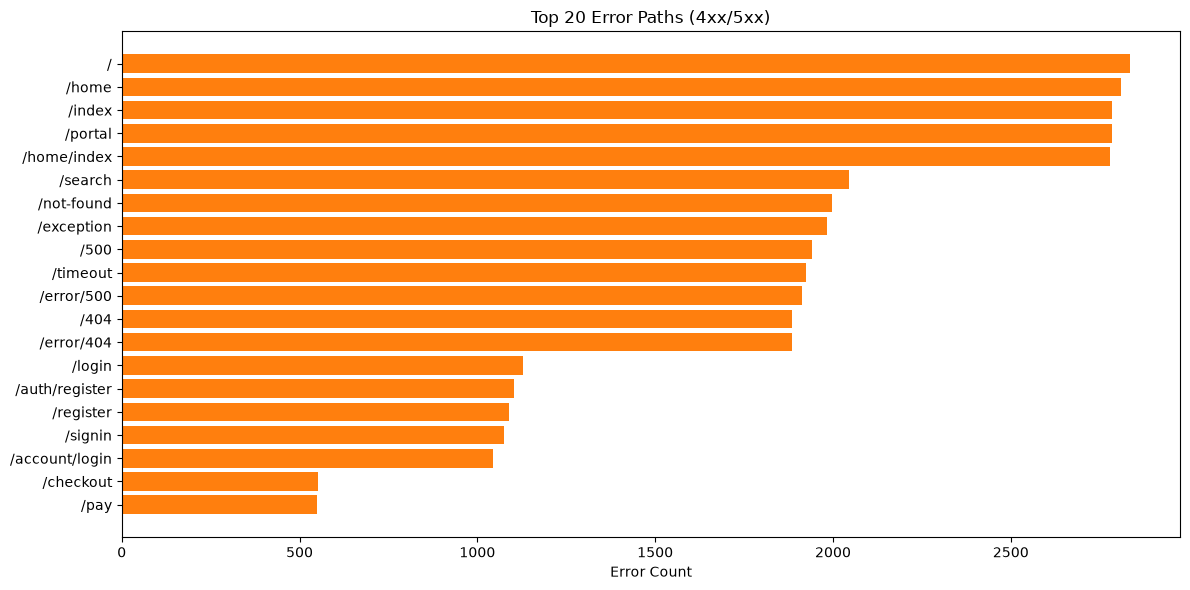

分析完成，结果与图片保存在: G:\Log-Spark-Insight-Analysis-v2\output_abnormal_analytics


In [10]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("\n=== 3+. HTTP 异常（4xx/5xx/404/500）深入分析 ===")

# 1) 基本准备：总请求数
total_requests = log_ts.count()
print("total requests:", total_requests)

# 2) 全局状态码分布及百分比
status_stats = (
    log_ts.groupBy("status_code")
    .count()
    .withColumn("pct", (F.col("count") / F.lit(total_requests)) * 100)
    .orderBy(F.col("count").desc())
)
status_stats.show(200, truncate=False)
pd_status_stats = status_stats.toPandas()
pd_status_stats.attrs.clear()
pd_status_stats.to_parquet(os.path.join(out_dir, "04_http_abnormal_status_stats.parquet"), index=False)

# 3) 全局错误率（4xx / 5xx）, 以及具体 404/500 rate
global_errors = (
    log_ts.agg(
        F.count("*").alias("total_requests"),
        F.sum(F.when((F.col("status_code") >= 400) & (F.col("status_code") < 500), 1).otherwise(0)).alias("4xx_count"),
        F.sum(F.when((F.col("status_code") >= 500) & (F.col("status_code") < 600), 1).otherwise(0)).alias("5xx_count"),
        F.sum(F.when(F.col("status_code") == 404, 1).otherwise(0)).alias("404_count"),
        F.sum(F.when(F.col("status_code") == 500, 1).otherwise(0)).alias("500_count"),
    )
    .withColumn("4xx_rate_pct", F.col("4xx_count") / F.col("total_requests") * 100)
    .withColumn("5xx_rate_pct", F.col("5xx_count") / F.col("total_requests") * 100)
    .withColumn("404_rate_pct", F.col("404_count") / F.col("total_requests") * 100)
    .withColumn("500_rate_pct", F.col("500_count") / F.col("total_requests") * 100)
)
global_errors.show(truncate=False)
pd_global_errors = global_errors.toPandas()
pd_global_errors.attrs.clear()
pd_global_errors.to_parquet(os.path.join(out_dir, "05_http_abnormal_global_errors.parquet"), index=False)


# 4) 按 path / 按 ip 的错误统计 TopN（404 与 5xx）
topn = 50
path_errors = (
    log_ts.groupBy("path")
    .agg(
        F.count("*").alias("total"),
        F.sum(F.when((F.col("status_code") >= 400) & (F.col("status_code") < 500), 1).otherwise(0)).alias("4xx"),
        F.sum(F.when((F.col("status_code") >= 500) & (F.col("status_code") < 600), 1).otherwise(0)).alias("5xx"),
        F.sum(F.when(F.col("status_code") == 404, 1).otherwise(0)).alias("404"),
        F.sum(F.when(F.col("status_code") == 500, 1).otherwise(0)).alias("500"),
    )
    .withColumn("404_rate_pct", F.col("404") / F.col("total") * 100)
    .withColumn("5xx_rate_pct", F.col("5xx") / F.col("total") * 100)
    .orderBy(F.desc("404"))
    .limit(topn)
)
print("\nTop paths by 404 count:")
path_errors.show(50, truncate=False)
pd_path_errors = path_errors.toPandas()
pd_path_errors.attrs.clear()
pd_path_errors.to_parquet(os.path.join(out_dir, "06_http_abnormal_path_errors.parquet"), index=False)


ip_errors = (
    log_ts.groupBy("ip")
    .agg(
        F.count("*").alias("total"),
        F.sum(F.when((F.col("status_code") >= 400) & (F.col("status_code") < 500), 1).otherwise(0)).alias("4xx"),
        F.sum(F.when((F.col("status_code") >= 500) & (F.col("status_code") < 600), 1).otherwise(0)).alias("5xx"),
    )
    .withColumn("4xx_rate_pct", F.col("4xx") / F.col("total") * 100)
    .withColumn("5xx_rate_pct", F.col("5xx") / F.col("total") * 100)
    .orderBy(F.desc("4xx"))
    .limit(topn)
)
print("\nTop IPs by 4xx count:")
ip_errors.show(50, truncate=False)
pd_ip_errors = ip_errors.toPandas()
pd_ip_errors.attrs.clear()
pd_ip_errors.to_parquet(os.path.join(out_dir, "07_http_abnormal_ip_errors.parquet"), index=False)

# 按小时和按日错误率
hourly = (
    log_ts
    .withColumn("date", F.to_date("ts"))
    .withColumn("hour", F.hour("ts"))
    .groupBy("date", "hour")
    .agg(
        F.count("*").alias("total"),
        F.sum(F.when((F.col("status_code") >= 400) & (F.col("status_code") < 500), 1).otherwise(0)).alias("4xx"),
        F.sum(F.when((F.col("status_code") >= 500) & (F.col("status_code") < 600), 1).otherwise(0)).alias("5xx"),
        F.sum(F.when(F.col("status_code")==404,1).otherwise(0)).alias("404"),
        F.sum(F.when(F.col("status_code")==500,1).otherwise(0)).alias("500"),
    )
    .withColumn("4xx_rate_pct", F.col("4xx")/F.col("total")*100)
    .withColumn("5xx_rate_pct", F.col("5xx")/F.col("total")*100)
    .withColumn("404_rate_pct", F.col("404")/F.col("total")*100)
    .withColumn("500_rate_pct", F.col("500")/F.col("total")*100)
    .orderBy("date","hour")
)
print("\nHourly error rates sample:")
hourly.show(200, truncate=False)
pd_hourly = hourly.toPandas()
pd_hourly.attrs.clear()
pd_hourly.to_parquet(os.path.join(out_dir, "08_http_abnormal_hourly_errors.parquet"), index=False)


daily = (
    log_ts
    .withColumn("date", F.to_date("ts"))
    .groupBy("date")
    .agg(
        F.count("*").alias("total"),
        F.sum(F.when((F.col("status_code") >= 400) & (F.col("status_code") < 500), 1).otherwise(0)).alias("4xx"),
        F.sum(F.when((F.col("status_code") >= 500) & (F.col("status_code") < 600), 1).otherwise(0)).alias("5xx"),
        F.sum(F.when(F.col("status_code")==404,1).otherwise(0)).alias("404"),
        F.sum(F.when(F.col("status_code")==500,1).otherwise(0)).alias("500"),
    )
    .withColumn("4xx_rate_pct", F.col("4xx")/F.col("total")*100)
    .withColumn("5xx_rate_pct", F.col("5xx")/F.col("total")*100)
    .withColumn("404_rate_pct", F.col("404")/F.col("total")*100)
    .withColumn("500_rate_pct", F.col("500")/F.col("total")*100)
    .orderBy("date")
)
print("\nDaily error rates sample:")
daily.show(200, truncate=False)
pd_daily = daily.toPandas()
pd_daily.attrs.clear()
pd_daily.to_parquet(os.path.join(out_dir, "09_http_abnormal_daily_errors.parquet"), index=False)

# 6) 错误集中度：帕累托（TopN 占比）与基尼系数（按 IP 或 path）
def compute_pareto_and_gini(sdf, group_col, error_col="error_count", total_col="total"):
    agg = (
        sdf.groupBy(group_col)
        .agg(
            F.count("*").alias(total_col),
            F.sum(F.when((F.col("status_code") >= 400) & (F.col("status_code") < 600), 1).otherwise(0)).alias(error_col)
        )
        .filter(F.col(total_col) > 0)
    )
    pdf = agg.select(group_col, total_col, error_col).toPandas()
    if pdf.shape[0]==0:
        return None
    pdf = pdf.sort_values(error_col, ascending=False).reset_index(drop=True)
    pdf["cum_error"] = pdf[error_col].cumsum()
    total_err = pdf[error_col].sum()
    pdf["cum_error_pct"] = pdf["cum_error"] / total_err * 100
    # Pareto: top 20% groups contribute多少错误
    top20_cut = int(max(1, np.floor(len(pdf) * 0.2)))
    pareto_pct = pdf.loc[:top20_cut-1, error_col].sum() / total_err * 100
    # Gini coefficient for error distribution
    vals = pdf[error_col].values
    vals = vals.astype(float)
    if vals.sum() == 0:
        gini = 0.0
    else:
        vals_sorted = np.sort(vals)
        n = len(vals_sorted)
        cumvals = np.cumsum(vals_sorted)
        gini = (2 * np.sum((np.arange(1, n+1) * vals_sorted)) ) / (n * vals_sorted.sum()) - (n + 1) / n
    return {"pareto_top20_pct": float(pareto_pct), "gini_error": float(gini), "group_count": len(pdf)}

pareto_ip = compute_pareto_and_gini(log_ts, "ip")
pareto_path = compute_pareto_and_gini(log_ts, "path")
print("\nPareto/Gini (IP):", pareto_ip)
print("Pareto/Gini (path):", pareto_path)

# 7) 按时间绘图（需要将小表转为 pandas）
# status distribution pie / bar (pandas)
# daily trend plot (stacked area for 2xx/3xx/4xx/5xx)

pdf_daily = daily.toPandas()
if not pdf_daily.empty:
    pdf_daily = pdf_daily.sort_values("date")
    pdf_daily["date"] = pd.to_datetime(pdf_daily["date"])
    # 为堆叠图准备不同 class counts
    # 计算按日各类 counts: 2xx,3xx,4xx,5xx
    def class_bucket(sc):
        if sc>=500: return "5xx"
        if sc>=400: return "4xx"
        if sc>=300: return "3xx"
        return "2xx"
    # 直接从原日志按日分桶聚合（更准确）
    agg_by_day = (
        log_ts.withColumn("date", F.to_date("ts"))
        .withColumn("class", F.when(F.col("status_code")>=500,"5xx")
                    .when(F.col("status_code")>=400,"4xx")
                    .when(F.col("status_code")>=300,"3xx")
                    .otherwise("2xx"))
        .groupBy("date","class").agg(F.count("*").alias("cnt"))
    )
    pdf_agg_by_day = agg_by_day.toPandas()
    pdf_pivot = pdf_agg_by_day.pivot(index="date", columns="class", values="cnt").fillna(0).sort_index()
    # 绘制堆叠面积图（按日）
    plt.figure(figsize=(10,5))
    pdf_pivot[["2xx","3xx","4xx","5xx"]].plot.area(colormap="tab20", stacked=True)
    plt.title("Daily status code stacked area")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir,"10_daily_stacked_status_area.png"))
    plt.close()

# hourly 404/500 rate 时间趋势图
pdf_hourly = hourly.toPandas()
if not pdf_hourly.empty:
    pdf_hourly["datetime"] = pd.to_datetime(pdf_hourly["date"].astype(str) + " " + pdf_hourly["hour"].astype(str) + ":00:00")
    pdf_hourly = pdf_hourly.sort_values("datetime")
    plt.figure(figsize=(12,4))
    plt.plot(pdf_hourly["datetime"], pdf_hourly["404_rate_pct"], label="404_rate_pct")
    plt.plot(pdf_hourly["datetime"], pdf_hourly["500_rate_pct"], label="500_rate_pct")
    plt.legend()
    plt.title("Hourly 404/500 rate (%)")
    plt.ylabel("Rate (%)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir,"11_hourly_404_500_rate.png"))
    plt.close()

# 8) Top error paths export (404 and 5xx)
top404_paths = path_errors.orderBy(F.desc("404")).limit(100)
top5xx_paths = (
    log_ts.groupBy("path")
    .agg(F.sum(F.when((F.col("status_code") >= 500) & (F.col("status_code") < 600),1).otherwise(0)).alias("5xx"))
    .orderBy(F.desc("5xx"))
    .limit(100)
)
pdf_top404_paths = top404_paths.toPandas()
pdf_top404_paths.attrs.clear()
pdf_top5xx_paths = top5xx_paths.toPandas()
pdf_top5xx_paths.attrs.clear()
pdf_top404_paths.to_parquet(os.path.join(out_dir,"12_top404_paths.parquet"), index=False)
pdf_top5xx_paths.to_parquet(os.path.join(out_dir,"13_top5xx_paths.parquet"), index=False)


# 9) 错误集中度 TopN 占比（示例：Top-20 path 占全部错误的比例）
path_err_tot = (
    log_ts.filter((F.col("status_code") >= 400) & (F.col("status_code") < 600))
    .groupBy("path").count().orderBy(F.desc("count"))
)
pdf_path_err = path_err_tot.toPandas()
pdf_path_err.attrs.clear()
if not pdf_path_err.empty:
    top20_err_pct = pdf_path_err.head(20)["count"].sum() / pdf_path_err["count"].sum() * 100
else:
    top20_err_pct = 0.0
print(f"Top-20 error paths account for {top20_err_pct:.2f}% of all errors")

pic_path_err = pdf_path_err.head(20).copy()
if not pic_path_err.empty:
    plt.figure(figsize=(12,6))
    plt.barh(pic_path_err['path'].astype(str)[::-1], pic_path_err['count'][::-1], color='C1')
    plt.xlabel('Error Count')
    plt.title('Top 20 Error Paths (4xx/5xx)')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, '14_top20_error_paths_bar.png'))
    plt.show()
else:
    print("没有错误路径数据可绘图")
print("分析完成，结果与图片保存在:", out_dir)

### 统计URL的错误率 - 忽略

### 慢请求分析扩展（响应时间 > 1000ms）

In [11]:
# 慢请求分析扩展（响应时间 ms）
print("\n=== 6. 慢请求分析扩展（>1000ms） ===")

from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 基本统计量（全量）
response_col = "response_time_ms"
resp_desc = log_ts.select(
    F.count("*").alias("count"),
    F.avg(response_col).alias("mean"),
    F.expr(f"percentile_approx({response_col}, 0.5)").alias("p50"),
    F.expr(f"percentile_approx({response_col}, 0.9)").alias("p90"),
    F.expr(f"percentile_approx({response_col}, 0.95)").alias("p95"),
    F.expr(f"percentile_approx({response_col}, 0.99)").alias("p99"),
    F.min(response_col).alias("min"),
    F.max(response_col).alias("max")
).collect()[0].asDict()
# 计算标准差（Spark 的 stddev）
std_row = log_ts.select(F.stddev(response_col).alias("stddev")).collect()[0].asDict()
resp_desc.update(std_row)

print("响应时间统计（ms）：", resp_desc)

# 更详细的分位（可选使用 approx）
quantiles = log_ts.approxQuantile(response_col, [0.5, 0.9, 0.95, 0.99], 0.01)
print("approx quantiles (p50,p90,p95,p99):", quantiles)

# 定义慢请求阈值：支持固定阈值或基于 P95
thresholds = {
    "1s": 1000,
    "3s": 3000,
    "p95": int(resp_desc.get("p95") or quantiles[2])
}

# 统计慢请求占比与Top路径（多阈值）
total_requests = log_ts.count()
slow_summary = []
for name,thr in thresholds.items():
    slow_df = log_ts.filter(F.col(response_col) > thr)
    cnt = slow_df.count()
    pct = cnt / total_requests * 100 if total_requests>0 else 0.0
    slow_summary.append({"threshold": name, "threshold_ms": thr, "count": cnt, "pct": pct})
    # Top 路径：按慢请求数量、按 avg response ms、按 p95 排序
    top_by_count = slow_df.groupBy("path").count().orderBy(F.desc("count")).limit(20)
    top_by_avg = slow_df.groupBy("path").agg(F.avg(response_col).alias("avg_ms"), F.count("*").alias("cnt")).orderBy(F.desc("avg_ms")).limit(20)
    top_by_p95 = slow_df.groupBy("path").agg(F.expr(f"percentile_approx({response_col}, 0.95)").alias("p95_ms"), F.count("*").alias("cnt")).orderBy(F.desc("p95_ms")).limit(20)

    # 保存 top tables
    pdf_top_by_count = top_by_count.toPandas()
    pdf_top_by_count.attrs.clear()
    pdf_top_by_count.to_parquet(os.path.join(out_dir, f"15_slow_top_count_{name}.parquet"), index=False)

    pdf_top_by_avg = top_by_avg.toPandas()
    pdf_top_by_avg.attrs.clear()
    pdf_top_by_avg.to_parquet(os.path.join(out_dir, f"16_slow_top_avg_{name}.parquet"), index=False)

    pdf_top_by_p95 = top_by_p95.toPandas()
    pdf_top_by_p95.attrs.clear()
    pdf_top_by_p95.to_parquet(os.path.join(out_dir, f"17_slow_top_p95_{name}.parquet"), index=False)

print("慢请求阈值摘要:", slow_summary)

# 分布可视化：先采样到 Pandas（避免 OOM，按比例或 limit）
sample_frac = 0.02
sample_count = max(100000, int(total_requests * sample_frac))
pdf = log_ts.select(response_col, "method", "status_code", "ip", "ts").orderBy(F.rand()).limit(sample_count).toPandas()
pdf.attrs.clear()
pdf = pdf.dropna(subset=[response_col])
pdf[response_col] = pd.to_numeric(pdf[response_col], errors="coerce").fillna(0)


# 绘图设置
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,5))
# 直方图 + KDE (log scale x 以便观察长尾)
plt.subplot(2,2,1)
sns.histplot(pdf[response_col], bins=100, kde=True)
plt.title("Response time histogram (ms)")
plt.xlabel("ms")

# 箱线图（raw）
plt.subplot(2,2,2)
sns.boxplot(x=pdf[response_col])
plt.title("Boxplot of response time (ms)")

# 小提琴图（按方法分层）
plt.subplot(2,2,3)
top_methods = pdf["method"].value_counts().index[:6]
pdf_m = pdf[pdf["method"].isin(top_methods)]
sns.violinplot(x="method", y=response_col, data=pdf_m)
plt.title("Violin plot by HTTP method")
plt.yscale("linear")

# 若响应时间长尾严重，绘制 log-scale 直方图（右下）
plt.subplot(2,2,4)
sns.histplot(np.log1p(pdf[response_col]), bins=100, kde=True)
plt.title("Log(1+ms) histogram")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "18_response_time_distribution.png"))
plt.close()

# 慢请求分层分析示例：按 method / status_code / 内外网（假设内网 IP 以 10./192.168./172.16-31 开头）
# 增加一个列判断内网/外网（Pandas 方式在 sample 上演示；Spark 上可以解析更精确）
def ip_type(ip):
    if str(ip).startswith(("10.","192.168.")) or (str(ip).startswith("172.") and 16 <= int(str(ip).split(".")[1]) <= 31):
        return "private"
    return "public"
pdf["ip_type"] = pdf["ip"].apply(ip_type)
# 按 method/stauts/ip_type 统计均值/中位数/p95
group_cols = ["method","status_code","ip_type"]
g = pdf.groupby(group_cols)[response_col].agg(["count","mean", "median", lambda x: np.percentile(x,95)])
g = g.rename(columns={"<lambda_0>":"p95_ms"})
g.attrs.clear()
g.reset_index().to_parquet(os.path.join(out_dir, "19_response_by_method_status_iptype.parquet"), index=False)

# 趋势：按分钟/小时进行时间序列（基于 sample 的近似）
if "ts" in pdf.columns:
    pdf["ts"] = pd.to_datetime(pdf["ts"])
    pdf["date_min"] = pdf["ts"].dt.floor("min")
    trend = pdf.groupby("date_min")[response_col].agg(["count","mean", lambda x: np.percentile(x,95)])
    trend = trend.rename(columns={"<lambda_0>":"p95_ms"}).reset_index()
    trend.attrs.clear()
    trend.to_parquet(os.path.join(out_dir, "20_response_time_trend.parquet"), index=False)
    # 绘图
    plt.figure(figsize=(12,4))
    plt.plot(trend["date_min"], trend["mean"], label="mean_ms")
    plt.plot(trend["date_min"], trend["p95_ms"], label="p95_ms")
    plt.legend()
    plt.title("Response time trend (sampled)")
    plt.xlabel("time")
    plt.ylabel("ms")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "21_response_time_trend.png"))
    plt.close()

# 输出 Top 慢路径总体表（按全量计算 avg/p95/count）
top_paths_full = (log_ts.groupBy("path")
                  .agg(
                      F.count("*").alias("cnt"),
                      F.avg(response_col).alias("avg_ms"),
                      F.expr(f"percentile_approx({response_col}, 0.95)").alias("p95_ms")
                  )
                  .orderBy(F.desc("avg_ms"))
                  .limit(200))
pdf_top_paths_full = top_paths_full.toPandas()
pdf_top_paths_full.attrs.clear()
pdf_top_paths_full.to_parquet(os.path.join(out_dir, "22_top_paths_overall_response.parquet"), index=False)

print("慢请求分析完成，结果保存在：", out_dir)


=== 6. 慢请求分析扩展（>1000ms） ===
响应时间统计（ms）： {'count': 600000, 'mean': 812.6388666666667, 'p50': 383, 'p90': 2666, 'p95': 3689, 'p99': 4837, 'min': 20, 'max': 14999, 'stddev': 1265.8802792250342}
approx quantiles (p50,p90,p95,p99): [np.float64(381.0), np.float64(2510.0), np.float64(3508.0), np.float64(14999.0)]
慢请求阈值摘要: [{'threshold': '1s', 'threshold_ms': 1000, 'count': np.int64(108625), 'pct': np.float64(18.104166666666664)}, {'threshold': '3s', 'threshold_ms': 3000, 'count': np.int64(50249), 'pct': np.float64(8.374833333333333)}, {'threshold': 'p95', 'threshold_ms': 3689, 'count': np.int64(30050), 'pct': np.float64(5.008333333333334)}]
慢请求分析完成，结果保存在： G:\Log-Spark-Insight-Analysis-v2\output_abnormal_analytics


In [14]:
# 检查慢请求占比突增（按分钟）
from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# 参数（可调整）
response_col = "response_time_ms"
slow_threshold_ms = 1000          # 慢请求阈值
agg_granularity = "yyyy-MM-dd HH:mm"  # 每分钟；改为 "yyyy-MM-dd HH" 表示每小时
baseline_window = 60              # 用过去 N 个点（分钟）做基线
z_thresh = 3.0                    # 均值+z*std 判定突增
rel_increase_thresh = 0.5        # 相对增长阈值：比历史均值增长 50% 视为突增

# 1) 用 Spark 计算每分钟统计：total / slow_count / slow_pct
per_min = (
    log_ts
    .withColumn("minute", F.date_format(F.col("ts"), agg_granularity))
    .groupBy("minute")
    .agg(
        F.count("*").alias("total"),
        F.sum(F.when(F.col(response_col) > slow_threshold_ms, 1).otherwise(0)).alias("slow_count")
    )
    .withColumn("slow_pct", (F.col("slow_count") / F.col("total")) * 100)
    .orderBy("minute")
)

# 2) 拉回 pandas（若数据非常大可先 limit 或采样）
pdf_min = per_min.toPandas()
if pdf_min.empty:
    print("没有分钟级数据，无法检测")
else:
    pdf_min["minute_dt"] = pd.to_datetime(pdf_min["minute"])
    pdf_min = pdf_min.sort_values("minute_dt").reset_index(drop=True)

    # 3) 计算滚动基线（past baseline_window 非包含当前点）
    pdf_min["baseline_mean"] = pdf_min["slow_pct"].rolling(window=baseline_window, min_periods=5).mean().shift(1)
    pdf_min["baseline_std"] = pdf_min["slow_pct"].rolling(window=baseline_window, min_periods=5).std().shift(1)

    # 4) 简单规则：均值+z*std 与 相对增长
    pdf_min["z_score"] = (pdf_min["slow_pct"] - pdf_min["baseline_mean"]) / pdf_min["baseline_std"].replace(0, np.nan)
    pdf_min["rel_increase"] = (pdf_min["slow_pct"] - pdf_min["baseline_mean"]) / pdf_min["baseline_mean"].replace(0, np.nan)

    pdf_min["anomaly_z"] = pdf_min["z_score"] > z_thresh
    pdf_min["anomaly_rel"] = pdf_min["rel_increase"] > rel_increase_thresh
    pdf_min["anomaly"] = pdf_min[["anomaly_z","anomaly_rel"]].any(axis=1)

    # 5) 导出异常点与时间序列
    pdf_min.attrs.clear()
    pdf_min.to_parquet(os.path.join(out_dir, "23_slow_pct_minute_series.parquet"), index=False)
    pdf_min[pdf_min["anomaly"]].to_parquet(os.path.join(out_dir, "24_slow_pct_minute_anomalies.parquet"), index=False)

    # 6) 绘图（含异常标注）
    plt.figure(figsize=(12,4))
    plt.plot(pdf_min["minute_dt"], pdf_min["slow_pct"], label="slow_pct(%)", color="C0")
    plt.plot(pdf_min["minute_dt"], pdf_min["baseline_mean"], label=f"baseline_mean({baseline_window})", color="C1", alpha=0.8)
    # 标注异常点
    anoms = pdf_min[pdf_min["anomaly"]]
    if not anoms.empty:
        plt.scatter(anoms["minute_dt"], anoms["slow_pct"], color="red", label="anomaly", zorder=5)
    plt.ylabel("slow_pct (%)")
    plt.xlabel("time")
    plt.title("Slow requests % per minute with anomalies")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "25_slow_pct_minute_anomalies.png"))
    plt.close()

    # 7) 简要打印发现
    print("总分钟点:", len(pdf_min), "异常点:", int(pdf_min['anomaly'].sum()))
    if int(pdf_min['anomaly'].sum())>0:
        display(pdf_min.loc[pdf_min['anomaly'], ["minute","total","slow_count","slow_pct","baseline_mean","baseline_std","z_score","rel_increase"]].head(50))
    else:
        print("未检测到明显的慢请求占比突增（按当前参数）。")

总分钟点: 14205 异常点: 2413


,minute,total,slow_count,slow_pct,baseline_mean,baseline_std,z_score,rel_increase
10,2024-01-01 08:10,12,3,25.000000,8.263522,5.273792,3.173519,2.025344
14,2024-01-01 08:14,7,1,14.285714,7.688230,7.496920,0.880026,0.858128
19,2024-01-01 08:19,8,2,25.000000,7.480156,7.091682,2.470478,2.342176
20,2024-01-01 08:20,12,2,16.666667,8.356148,7.936766,1.047091,0.994539
22,2024-01-01 08:22,20,3,15.000000,8.354074,7.975387,0.833305,0.795531
25,2024-01-01 08:25,11,4,36.363636,8.284918,7.771697,3.612946,3.389136
26,2024-01-01 08:26,5,1,20.000000,9.364869,9.397177,1.131737,1.135641
35,2024-01-01 08:35,14,2,14.285714,8.229335,8.996650,0.673182,0.735950
39,2024-01-01 08:39,8,2,25.000000,8.008011,8.773912,1.936649,2.121874
42,2024-01-01 08:42,10,2,20.000000,8.031249,9.028762,1.325625,1.490273


### 异常流量检测扩展

In [ ]:
# 13) 异常流量检测扩展（规则 + 统计 + IsolationForest）
print("\n=== 7. 异常流量检测（规则 + 统计 + IsolationForest） ===")

from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy import stats

# 1) 聚合到分钟级别并计算特征
agg_min = (
    log_ts
    .withColumn("minute", F.date_format(F.col("ts"), "yyyy-MM-dd HH:mm"))
    .groupBy("minute")
    .agg(
        F.count("*").alias("req_count"),
        F.countDistinct("ip").alias("uniq_ip"),
        F.countDistinct("path").alias("uniq_path"),
        F.avg("response_time_ms").alias("avg_resp_ms"),
        F.expr("sum(case when status_code >= 400 and status_code < 600 then 1 else 0 end)").alias("error_count"),
        F.expr("sum(case when response_time_ms > 1000 then 1 else 0 end)").alias("slow_count")
    )
    .orderBy("minute")
)

# 衍生特征
agg_min = (
    agg_min
    .withColumn("error_rate", F.col("error_count") / F.col("req_count"))
    .withColumn("slow_pct", F.col("slow_count") / F.col("req_count"))
)

pdf_min = agg_min.toPandas()
# 下面两行是optional：
# 目的是：只保留 req_count >= 5 的分钟，避免单条请求引发假阳性
pdf_min.attrs.clear()
pdf_min = pdf_min[pdf_min["req_count"].fillna(0) >= 5].copy()

if pdf_min.empty:
    print("没有数据用于异常检测")
else:
    pdf_min["minute_dt"] = pd.to_datetime(pdf_min["minute"])
    pdf_min = pdf_min.set_index("minute_dt").sort_index()

    # 计算增长率（相对于前一分钟）
    pdf_min["req_growth"] = pdf_min["req_count"].pct_change().fillna(0)

    # 计算每分钟 top-ip 占比（单IP占比过高检测需要先计算每分钟内最大单IP比例）
    per_min_ip = (
        log_ts
        .withColumn("minute", F.date_format(F.col("ts"), "yyyy-MM-dd HH:mm"))
        .groupBy("minute", "ip")
        .agg(F.count("*").alias("cnt"))
    )
    # 获取每分钟最大 ip 占比
    w = Window.partitionBy("minute")
    per_min_ip_max = (
        per_min_ip
        .withColumn("minute_total", F.sum("cnt").over(w))
        .withColumn("ip_pct", F.col("cnt") / F.col("minute_total"))
        .groupBy("minute")
        .agg(F.max("ip_pct").alias("max_ip_pct"))
    )
    pdf_ip_pct = per_min_ip_max.toPandas()
    if not pdf_ip_pct.empty:
        pdf_ip_pct["minute_dt"] = pd.to_datetime(pdf_ip_pct["minute"])
        pdf_ip_pct = pdf_ip_pct.set_index("minute_dt").sort_index()
        pdf_min = pdf_min.join(pdf_ip_pct[["max_ip_pct"]], how="left").fillna(0)

    # 特征列表
    features = ["req_count", "uniq_ip", "uniq_path", "req_growth", "avg_resp_ms", "error_rate", "slow_pct", "max_ip_pct"]

    # 2) 统计检测（移动均值+3σ、P99、Z-score、IQR、CUSUM）
    stats_df = pdf_min.copy()
    window = 60  # 用过去 60 分钟作历史基线
    for f in ["req_count", "error_rate", "req_growth", "max_ip_pct"]:
        stats_df[f"{f}_ma"] = stats_df[f].rolling(window=window, min_periods=5).mean()
        stats_df[f"{f}_std"] = stats_df[f].rolling(window=window, min_periods=5).std().fillna(0)
        stats_df[f"{f}_z"] = (stats_df[f] - stats_df[f"{f}_ma"]) / (stats_df[f"{f}_std"].replace(0, np.nan))
        stats_df[f"{f}_z"] = stats_df[f"{f}_z"].fillna(0)
        # IQR
        q1 = stats_df[f].rolling(window=window, min_periods=5).quantile(0.25)
        q3 = stats_df[f].rolling(window=window, min_periods=5).quantile(0.75)
        iqr = (q3 - q1).fillna(0)
        stats_df[f"{f}_upper_iqr"] = q3 + 1.5 * iqr
        stats_df[f"{f}_cusum_pos"] = (stats_df[f] - stats_df[f"{f}_ma"]).clip(lower=0).cumsum()

    # 规则检测标志
    stats_df["rule_spike_ma3x"] = (stats_df["req_count"] > stats_df["req_count_ma"] * 3).astype(int)
    # P99 基线（基于历史窗口）
    stats_df["req_p99"] = stats_df["req_count"].rolling(window=window, min_periods=5).quantile(0.99).fillna(0)
    stats_df["rule_spike_p99"] = (stats_df["req_count"] > stats_df["req_p99"]).astype(int)
    stats_df["rule_high_ip_pct"] = (stats_df["max_ip_pct"] > 0.5).astype(int)  # 单IP占比>50% 视为可疑（可调整）
    stats_df["rule_error_spike"] = ((stats_df["error_rate"] > stats_df["error_rate_ma"] * 3) & (stats_df["req_count"] > stats_df["req_count_ma"] * 1.5)).astype(int)

    # 3) IsolationForest（对时间窗口打分）
    # 使用滑动窗口上每分钟的特征做训练（去掉NaN/inf）
    clf_features = stats_df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
    scaler = StandardScaler()
    X = scaler.fit_transform(clf_features)
    iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
    iso_scores = iso.fit_predict(X)
    iso_anom_score = -iso.score_samples(X)  # 越大越异常
    stats_df["iso_score"] = iso_anom_score
    stats_df["iso_label"] = (iso_scores == -1).astype(int)

    # 综合异常分数（标准化后加权）
    stats_df["iso_score_z"] = stats_df["iso_score"].rank(pct=True)
    stats_df["rule_score"] = stats_df[["rule_spike_ma3x", "rule_spike_p99", "rule_high_ip_pct", "rule_error_spike"]].sum(axis=1)
    stats_df["combined_score"] = stats_df["iso_score_z"] * 0.7 + (stats_df["rule_score"] / 4.0) * 0.3

    # 导出异常时间点（按 combined_score 排序，阈值可调整）
    anomalies_time = stats_df[stats_df["combined_score"] > stats_df["combined_score"].quantile(0.95)].sort_values("combined_score", ascending=False)
    anomalies_time_out = anomalies_time.reset_index().rename(columns={"index":"minute"})
    anomalies_time_out.to_parquet(os.path.join(out_dir, "26_anomalous_minutes.parquet"), index=False)
    print("异常时间点（Top 20）：")
    print(anomalies_time_out.head(20)[["minute","combined_score","iso_score_z","rule_score","req_count","error_rate","max_ip_pct"]])

    # 4) IP 级别异常：对每个 ip 在一段时间窗口内（例如过去 7 天或整个样本）构建特征并做 IsolationForest
    # 计算每 ip 的总请求数、平均每分钟请求、错误率、路径多样性(user path entropy)、ua 多样性等
    from math import log2
    ip_agg = (
        log_ts
        .groupBy("ip")
        .agg(
            F.count("*").alias("total_reqs"),
            F.countDistinct(F.date_format(F.col("ts"), "yyyy-MM-dd HH:mm")).alias("active_minutes"),
            F.countDistinct("path").alias("uniq_paths"),
            F.countDistinct("user_agent").alias("uniq_uas"),
            F.sum(F.when((F.col("status_code")>=400)&(F.col("status_code")<600),1).otherwise(0)).alias("errors"),
            F.avg("response_time_ms").alias("avg_resp_ms")
        )
    )
    pdf_ip = ip_agg.toPandas()
    if not pdf_ip.empty:
        pdf_ip["req_per_min"] = pdf_ip["total_reqs"] / pdf_ip["active_minutes"].replace(0,1)
        pdf_ip["error_rate"] = pdf_ip["errors"] / pdf_ip["total_reqs"].replace(0,1)
        # 路径多样性用简单 Shannon 熵（近似：基于样本计数需从 Spark 单独计算；这里用 uniq_paths 近似）
        pdf_ip["path_diversity"] = pdf_ip["uniq_paths"]
        ip_features = ["total_reqs","req_per_min","error_rate","uniq_paths","uniq_uas","avg_resp_ms","path_diversity"]
        ip_X = pdf_ip[ip_features].replace([np.inf,-np.inf],np.nan).fillna(0)
        scaler_ip = StandardScaler()
        Xip = scaler_ip.fit_transform(ip_X)
        iso_ip = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
        ip_scores = iso_ip.fit_predict(Xip)
        ip_anom_score = -iso_ip.score_samples(Xip)
        pdf_ip["iso_score"] = ip_anom_score
        pdf_ip["iso_label"] = (ip_scores == -1).astype(int)
        pdf_ip = pdf_ip.sort_values("iso_score", ascending=False)
        pdf_ip.reset_index(inplace=True)
        pdf_ip.rename(columns={"index":"ip_index"}, inplace=True)
        pdf_ip.attrs.clear()
        pdf_ip.to_parquet(os.path.join(out_dir, "27_ip_anomaly_scores.parquet"), index=False)
        print("\n异常IP Top 20：")
        print(pdf_ip.head(20)[["ip","iso_score","iso_label","total_reqs","req_per_min","error_rate","uniq_paths","uniq_uas"]])
    else:
        print("没有 IP 数据用于 IP 级别异常检测")

    # 5) 输出综合异常列表（时间 + 各种分数），供人工标注和后续评估
    stats_df.reset_index(inplace=True)
    out_cols = ["minute","req_count","uniq_ip","uniq_path","req_growth","avg_resp_ms","error_rate","slow_pct","max_ip_pct",
                "rule_spike_ma3x","rule_spike_p99","rule_high_ip_pct","rule_error_spike",
                "iso_score","iso_label","rule_score","combined_score"]
    stats_df[out_cols].to_parquet(os.path.join(out_dir, "28_minute_level_anomaly_scores.parquet"), index=False)

    print("\n保存文件到:", out_dir)
    print("Task finished.")


=== 7. 异常流量检测（规则 + 统计 + IsolationForest） ===
异常时间点（Top 20）：
              minute  combined_score  iso_score_z  rule_score  req_count  \
0   2024-01-02 02:57        0.772847     0.996925           1        159   
1   2024-01-01 19:02        0.771964     0.995663           1        150   
2   2024-01-02 00:05        0.771854     0.995505           1        157   
3   2024-01-01 20:03        0.770032     0.992903           1        155   
4   2024-01-02 01:09        0.769536     0.992194           1        160   
5   2024-01-01 20:35        0.769370     0.991957           1        167   
6   2024-01-02 01:14        0.769260     0.991799           1        164   
7   2024-01-01 23:58        0.767328     0.989040           1        150   
8   2024-01-10 16:04        0.766445     0.987778           1         11   
9   2024-01-02 19:01        0.765175     0.985964           1        123   
10  2024-01-01 23:56        0.764237     0.984624           1        141   
11  2024-01-01 18:26       

In [ ]:
# 18) 保存分析结果到 HDFS
# out_base = f"{hdfs_base}/spark/httplog_analytics/results"
# country_stats.write.mode("overwrite").parquet(f"{out_base}/country_stats")
# category_stats.write.mode("overwrite").parquet(f"{out_base}/category_stats")
# status_stats.write.mode("overwrite").parquet(f"{out_base}/status_stats")
# hourly_stats.write.mode("overwrite").parquet(f"{out_base}/hourly_stats")
# daily_error.write.mode("overwrite").parquet(f"{out_base}/daily_error")
# anomaly_ip_stats.write.mode("overwrite").parquet(f"{out_base}/anomaly_ip_stats")
# path_stats.write.mode("overwrite").parquet(f"{out_base}/path_stats")
# response_summary.write.mode("overwrite").parquet(f"{out_base}/response_summary")
# high_risk_country.write.mode("overwrite").parquet(f"{out_base}/high_risk_country")


# print("\n=== 分析结果已写入 HDFS ===")
# print(f"结果目录：{out_base}")


In [32]:
# 19) 关闭 Spark
spark.stop()